# nb03 — RNA-ATAC Relationship (Multiome)
Characterize the chromatin accessibility -> gene expression relationship at single-cell resolution.

Uses the pre-computed `obsm['ATAC_gene_activity']` (gene-level accessibility) instead of manual peak-to-gene linkage — see SESSION_MEMORY.md / DATA.md for why.

## Environment setup (Colab or local)

In [2]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics-relationship-modeling


## Imports and config

In [3]:
import sys
sys.path.insert(0, str(BASE_PATH))

import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from src.analysis.coupling import per_gene_pearson, coupling_score_by_celltype, deviation_score

DATA_DIR = BASE_PATH / 'data' / 'benchmark'
MULTIOME_H5AD = DATA_DIR / 'GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'

RESULTS_DIR = BASE_PATH / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR  = RESULTS_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MIN_CELLS_PER_TYPE = 50
RANDOM_STATE = 42

## Load Multiome and split GEX from ATAC

In [4]:
multiome = sc.read_h5ad(MULTIOME_H5AD)

gex_mask  = multiome.var['feature_types'] == 'GEX'
multi_gex = multiome[:, gex_mask].copy()

print(f'GEX: {multi_gex.shape}')
print(f"ATAC_gene_activity (obsm): {multiome.obsm['ATAC_gene_activity'].shape}")
print(f"ATAC gene activity var names (first 10): {multiome.uns['ATAC_gene_activity_var_names'][:10]}")

GEX: (69249, 13431)
ATAC_gene_activity (obsm): (69249, 19039)
ATAC gene activity var names (first 10): ['OR4F5' 'OR4F29' 'OR4F16' 'SAMD11' 'NOC2L' 'KLHL17' 'PLEKHN1' 'PERM1'
 'HES4' 'ISG15']


In [21]:
multiome

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

## Step 1 — Match GEX genes to ATAC_gene_activity genes
Both use clean gene symbols, so this should be a near-direct match (no CD-mapping needed like nb02).

In [5]:
atac_gene_names = list(multiome.uns['ATAC_gene_activity_var_names'])
gex_gene_names  = list(multi_gex.var_names)

common_genes = sorted(set(atac_gene_names) & set(gex_gene_names))
print(f'GEX genes: {len(gex_gene_names)}')
print(f'ATAC gene activity genes: {len(atac_gene_names)}')
print(f'Common genes: {len(common_genes)}')

GEX genes: 13431
ATAC gene activity genes: 19039
Common genes: 11461


In [22]:
atac_mask = multiome.var['feature_types'] == 'ATAC'
atac_var = multiome.var[atac_mask]

print(atac_var.columns.tolist())
print(atac_var.head(10))
print()
print('Index (peak names) sample:')
print(atac_var.index[:10].tolist())

['feature_types', 'gene_id']
                   feature_types gene_id
chr1-9776-10668             ATAC     NaN
chr1-180726-181005          ATAC     NaN
chr1-181117-181803          ATAC     NaN
chr1-191133-192055          ATAC     NaN
chr1-267562-268456          ATAC     NaN
chr1-629497-630394          ATAC     NaN
chr1-633515-634474          ATAC     NaN
chr1-778276-779191          ATAC     NaN
chr1-816868-817761          ATAC     NaN
chr1-822804-823597          ATAC     NaN

Index (peak names) sample:
['chr1-9776-10668', 'chr1-180726-181005', 'chr1-181117-181803', 'chr1-191133-192055', 'chr1-267562-268456', 'chr1-629497-630394', 'chr1-633515-634474', 'chr1-778276-779191', 'chr1-816868-817761', 'chr1-822804-823597']


In [23]:
print(multiome.uns['genome'])
print(multiome.uns['organism'])

GRCh38
human


## Step 2 — Check ATAC_gene_activity distribution before correlating
Decide on transform based on what we see — no blind log-transform.

In [6]:
atac_activity = multiome.obsm['ATAC_gene_activity']
atac_activity = np.asarray(atac_activity.todense()) if hasattr(atac_activity, 'todense') else np.asarray(atac_activity)

atac_df_full = pd.DataFrame(atac_activity, columns=atac_gene_names, index=multiome.obs_names)
atac_sub_check = atac_df_full[common_genes].values

print('ATAC_gene_activity stats (matched genes only):')
print(f'  min: {atac_sub_check.min():.4f}')
print(f'  max: {atac_sub_check.max():.4f}')
print(f'  mean: {atac_sub_check.mean():.4f}')
print(f'  median: {np.median(atac_sub_check):.4f}')
print(f'  % zeros: {(atac_sub_check == 0).mean()*100:.1f}%')
print(f'  skew (sample of 1000 cells, 1 gene): {pd.Series(atac_sub_check[:1000, 0]).skew():.2f}')

ATAC_gene_activity stats (matched genes only):
  min: 0.0000
  max: 7.0664
  mean: 0.3292
  median: 0.0000
  % zeros: 60.4%
  skew (sample of 1000 cells, 1 gene): 2.03


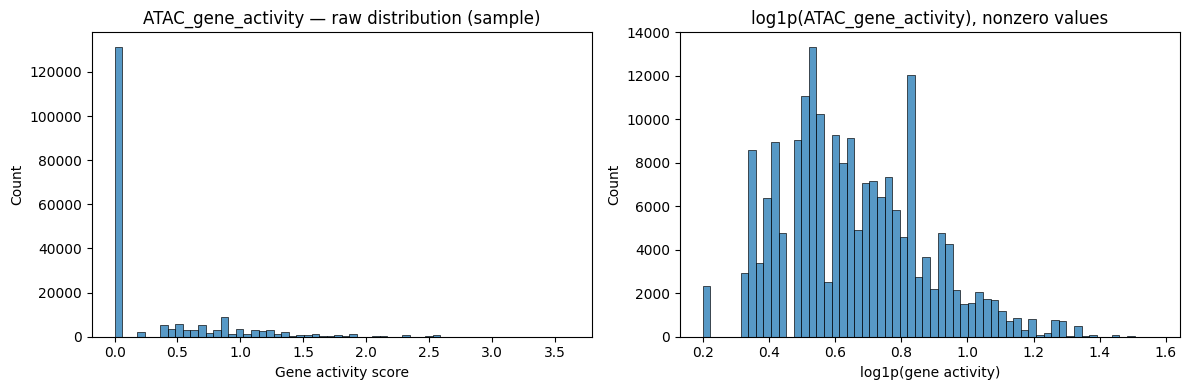

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(atac_sub_check.flatten()[:200000], bins=60, ax=axes[0])
axes[0].set_title('ATAC_gene_activity — raw distribution (sample)')
axes[0].set_xlabel('Gene activity score')

nonzero_vals = atac_sub_check.flatten()
nonzero_vals = nonzero_vals[nonzero_vals > 0][:200000]
sns.histplot(np.log1p(nonzero_vals), bins=60, ax=axes[1])
axes[1].set_title('log1p(ATAC_gene_activity), nonzero values')
axes[1].set_xlabel('log1p(gene activity)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_atac_activity_distribution.png', dpi=150)
plt.show()

### Decision point
Based on the distribution above: if heavily right-skewed / zero-inflated (typical for ATAC), apply log1p before correlating. Set the flag below accordingly.

In [8]:
APPLY_LOG1P_TO_ATAC = True  # set based on distribution check above

print(f'Applying log1p to ATAC_gene_activity: {APPLY_LOG1P_TO_ATAC}')

Applying log1p to ATAC_gene_activity: True


## Step 3 — Build aligned matrices for overlapping genes

In [9]:
gex_sub = multi_gex[:, common_genes].X
gex_sub = np.asarray(gex_sub.todense()) if hasattr(gex_sub, 'todense') else np.asarray(gex_sub)

atac_sub = atac_df_full[common_genes].values
if APPLY_LOG1P_TO_ATAC:
    atac_sub = np.log1p(atac_sub)

print(f'GEX matrix: {gex_sub.shape}')
print(f'ATAC matrix: {atac_sub.shape}')
assert gex_sub.shape == atac_sub.shape

GEX matrix: (69249, 11461)
ATAC matrix: (69249, 11461)


## Step 4 — Per-gene RNA-ATAC correlation (all cells)

In [16]:
gene_corr_atac = per_gene_pearson(gex_sub, atac_sub, common_genes, min_cells=MIN_CELLS_PER_TYPE)
gene_corr_atac.to_csv(TABLES_DIR / 'nb03_gene_rna_atac_corr.csv', index=False)

print(f'Median Pearson r: {gene_corr_atac["pearson_r"].median():.3f}')
print(f'Mean Pearson r: {gene_corr_atac["pearson_r"].mean():.3f}')
gene_corr_atac.head(10)

Median Pearson r: -0.300
Mean Pearson r: -0.293


,gene,pearson_r,p_value
4038,HBB,0.293351,0.000000e+00
10567,VCAN,0.265782,0.000000e+00
414,ANK1,0.179246,1.797084e-300
4036,HBA1,0.177512,4.260883e-247
2807,EBF1,0.173185,1.681412e-229
7057,PLXDC2,0.163629,4.085687e-194
8817,SLC4A1,0.160853,5.023242e-106
1285,CA1,0.157215,9.758411e-90
7330,PRKCH,0.154607,2.500341e-307
9922,TNFAIP3,0.154171,1.138752e-247


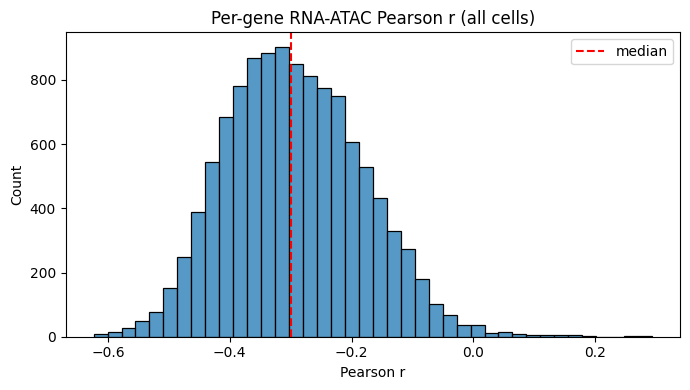

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(gene_corr_atac['pearson_r'], bins=40, ax=ax)
ax.set_title('Per-gene RNA-ATAC Pearson r (all cells)')
ax.set_xlabel('Pearson r')
ax.axvline(gene_corr_atac['pearson_r'].median(), color='red', linestyle='--', label='median')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_gene_corr_histogram.png', dpi=150)
plt.show()

In [12]:
print('--- Top 15 most coupled genes (RNA-ATAC) ---')
display(gene_corr_atac.head(15))

print('--- Top 15 most independent genes (lowest r) ---')
display(gene_corr_atac.tail(15))

--- Top 15 most coupled genes (RNA-ATAC) ---


,gene,pearson_r,p_value
4038,HBB,0.293351,0.000000e+00
10567,VCAN,0.265782,0.000000e+00
414,ANK1,0.179246,1.797084e-300
4036,HBA1,0.177512,4.260883e-247
2807,EBF1,0.173185,1.681412e-229
7057,PLXDC2,0.163629,4.085687e-194
8817,SLC4A1,0.160853,5.023242e-106
1285,CA1,0.157215,9.758411e-90
7330,PRKCH,0.154607,2.500341e-307
9922,TNFAIP3,0.154171,1.138752e-247


--- Top 15 most independent genes (lowest r) ---


,gene,pearson_r,p_value
9339,SUMO4,-0.590252,7.377997e-89
10315,U2AF1,-0.590584,0.000000e+00
640,ARL17A,-0.590707,0.000000e+00
5999,NBPF15,-0.594807,0.000000e+00
7881,RGPD5,-0.595087,2.873066e-303
7174,POU5F2,-0.596760,9.582004e-196
7879,RGPD1,-0.599985,4.555481e-107
3387,FCGR2B,-0.601374,1.831864e-286
6304,NPIPA5,-0.603568,3.808132e-74
6004,NBPF9,-0.605323,0.000000e+00


## Step 5 — Cell-type stratification

In [11]:
cell_types_multi = multi_gex.obs['cell_type'].values

ct_corr_atac = coupling_score_by_celltype(gex_sub, atac_sub, common_genes, cell_types_multi)
ct_corr_atac.to_csv(TABLES_DIR / 'nb03_celltype_gene_corr.csv')

print(f'Shape: {ct_corr_atac.shape} (genes x cell types)')
print(f'Cell types included (>= {MIN_CELLS_PER_TYPE} cells): {ct_corr_atac.shape[1]}')
ct_corr_atac.head()

Shape: (11461, 22) (genes x cell types)
Cell types included (>= 50 cells): 22


,B1 B,CD14+ Mono,CD16+ Mono,CD4+ T activated,CD4+ T naive,CD8+ T,CD8+ T naive,Erythroblast,G/M prog,HSC,...,Lymph prog,MK/E prog,NK,Naive CD20+ B,Normoblast,Plasma cell,Proerythroblast,Transitional B,cDC2,pDC
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,-0.394790,-0.359682,-0.511045,-0.455295,-0.432927,-0.505310,-0.328566,-0.269376,-0.366020,-0.149921,...,-0.127530,-0.257626,-0.517693,-0.357876,-0.759530,-0.263408,-0.201139,-0.296281,-0.328721,-0.398514
A2M,-0.641450,-0.237295,-0.384932,-0.411768,-0.457998,-0.252716,-0.393747,-0.471203,-0.500794,-0.546181,...,-0.484745,-0.421095,-0.420887,-0.474498,NaN,NaN,-0.419469,-0.403669,-0.335649,-0.461645
AAAS,-0.120516,-0.159442,-0.238340,-0.237344,-0.202269,-0.302440,-0.227278,-0.227262,-0.225216,-0.191618,...,-0.181748,-0.146860,-0.248897,-0.182260,-0.386602,-0.290272,-0.180508,-0.193323,-0.129782,-0.218528
AACS,-0.231551,-0.270261,-0.258918,-0.418133,-0.354791,-0.454792,-0.260948,-0.213740,-0.213529,-0.281519,...,-0.257744,-0.257415,-0.431171,-0.346446,-0.427082,-0.131903,-0.232289,-0.283260,-0.302250,-0.254759
AAGAB,-0.369251,-0.358327,-0.513543,-0.463428,-0.454318,-0.436824,-0.358292,-0.402868,-0.305114,-0.294377,...,-0.233081,-0.319231,-0.445271,-0.394940,-0.526718,-0.330697,-0.303808,-0.405677,-0.255124,-0.348576


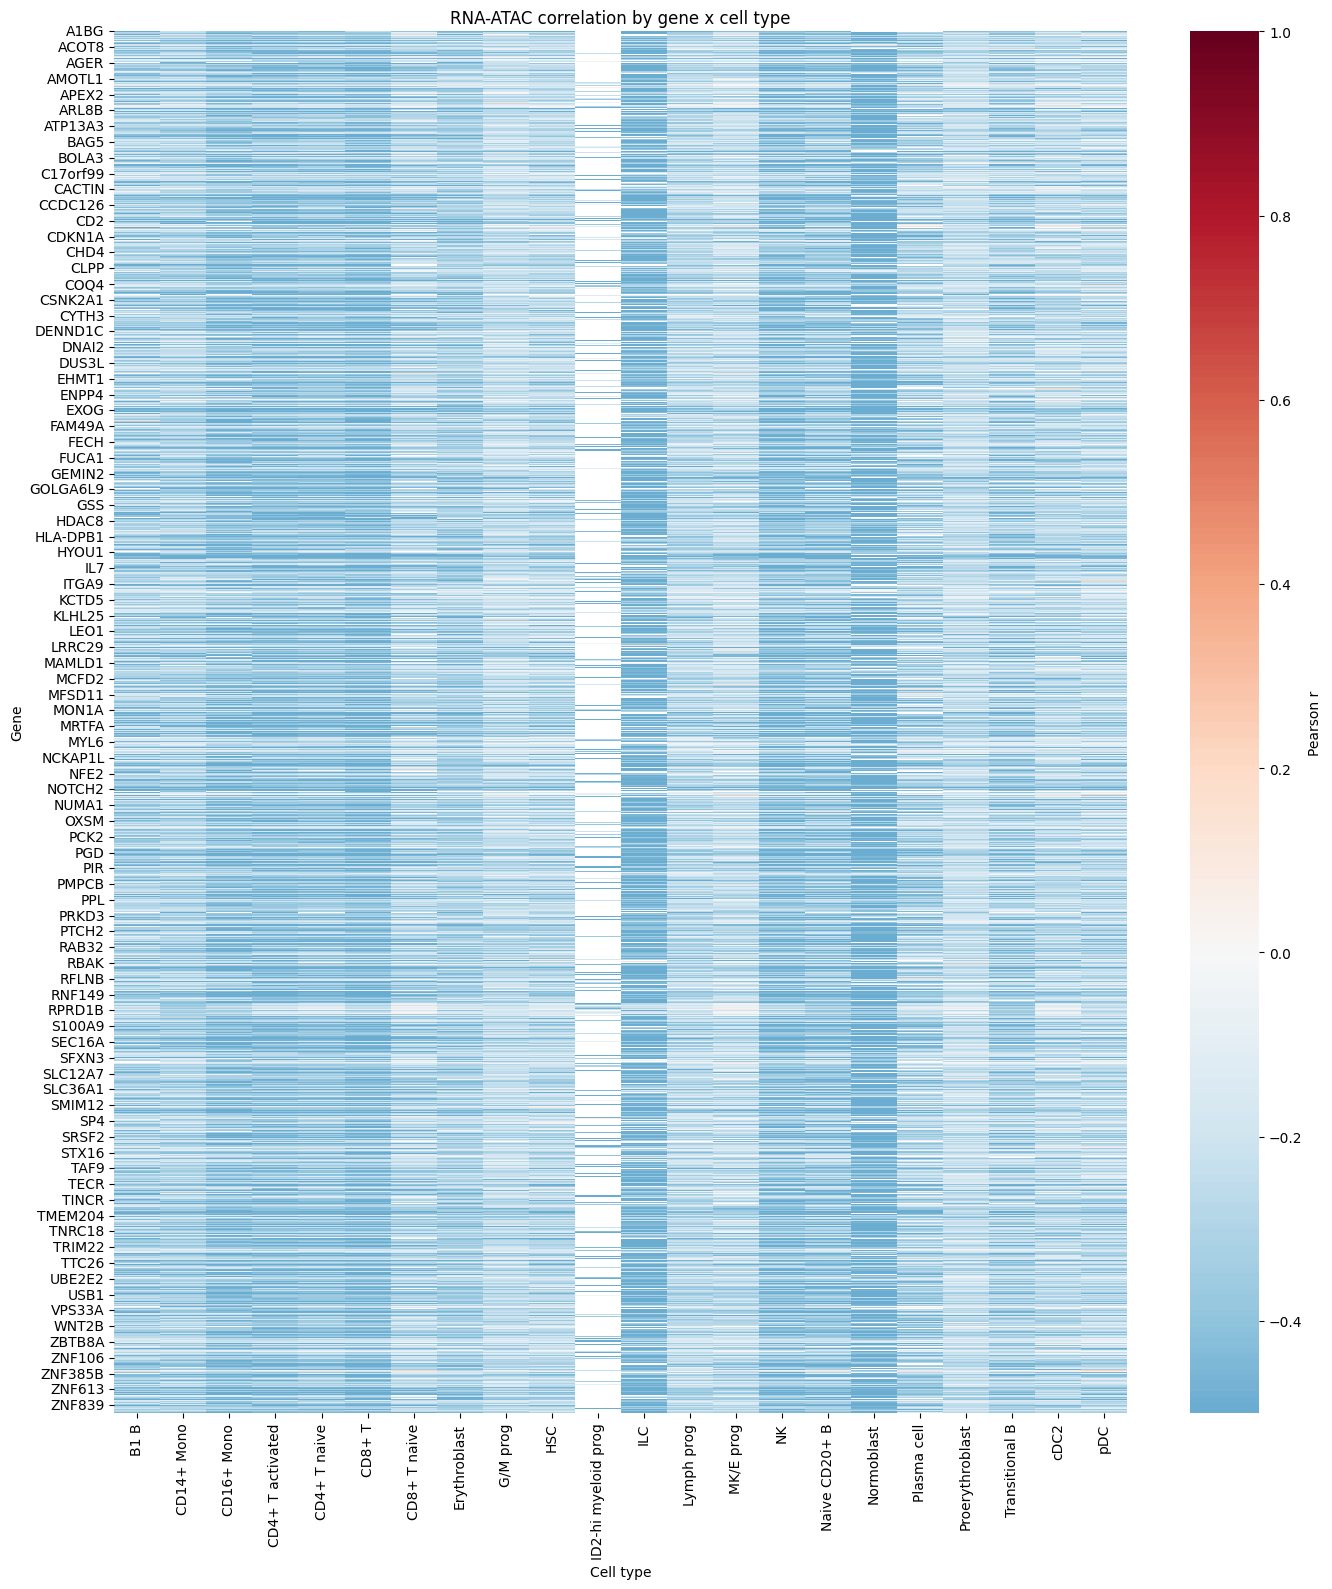

In [14]:
fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(ct_corr_atac, cmap='RdBu_r', center=0, vmin=-0.5, vmax=1.0,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('RNA-ATAC correlation by gene x cell type')
ax.set_xlabel('Cell type')
ax.set_ylabel('Gene')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_celltype_heatmap.png', dpi=150)
plt.show()

In [15]:
ct_variance_atac = ct_corr_atac.var(axis=1).sort_values(ascending=False)
ct_mean_atac = ct_corr_atac.mean(axis=1)

variability_df_atac = pd.DataFrame({
    'mean_r': ct_mean_atac,
    'variance_across_celltypes': ct_variance_atac
}).sort_values('variance_across_celltypes', ascending=False)

variability_df_atac.to_csv(TABLES_DIR / 'nb03_coupling_variability.csv')

print('--- Most cell-type-specific coupling (high variance) ---')
display(variability_df_atac.head(15))

print('--- Most universal coupling (low variance) ---')
display(variability_df_atac.sort_values('variance_across_celltypes').head(15))

--- Most cell-type-specific coupling (high variance) ---


,mean_r,variance_across_celltypes
gene,,
IL1B,-0.338872,0.082109
EREG,-0.374219,0.065864
PLXDC2,-0.241334,0.062065
TCF4,-0.207839,0.060599
ATP8B4,-0.248971,0.059661
EPB41L3,-0.284270,0.056690
NAMPT,-0.128959,0.056545
EBF1,-0.173443,0.055911
RNF144B,-0.390085,0.054118


--- Most universal coupling (low variance) ---


,mean_r,variance_across_celltypes
gene,,
NBPF20,-0.618629,0.001124
C19orf47,-0.150240,0.001236
ANKMY1,-0.176177,0.001269
HBB,0.015626,0.001445
HAUS8,-0.197128,0.001479
DNM1,-0.066242,0.001503
MTRNR2L12,-0.086874,0.001564
ZNF511,-0.263594,0.001612
CATSPER2,-0.597909,0.001754


## Step 6 — Donor consistency check

In [16]:
donors_multi = multi_gex.obs['DonorID'].values
unique_donors_multi = np.unique(donors_multi)
print(f'Donors: {len(unique_donors_multi)}')

donor_corrs_atac = {}
for donor in unique_donors_multi:
    mask = donors_multi == donor
    if mask.sum() < MIN_CELLS_PER_TYPE:
        continue
    df = per_gene_pearson(gex_sub[mask], atac_sub[mask], common_genes, min_cells=MIN_CELLS_PER_TYPE)
    donor_corrs_atac[donor] = df.set_index('gene')['pearson_r']

donor_corr_df_atac = pd.DataFrame(donor_corrs_atac)
donor_corr_df_atac.to_csv(TABLES_DIR / 'nb03_donor_gene_corr.csv')

print(f'Shape: {donor_corr_df_atac.shape} (genes x donors)')
donor_corr_df_atac.head()

Donors: 10
Shape: (11461, 10) (genes x donors)


,10886,11466,12710,13272,15078,16710,18303,19593,28045,28483
gene,,,,,,,,,,
A1BG,-0.507635,-0.056843,-0.323933,-0.426792,-0.385141,-0.529743,-0.266418,-0.321428,-0.093676,-0.258044
A2M,-0.433948,-0.515612,-0.503761,-0.585576,-0.527738,-0.382778,-0.446384,-0.408213,-0.576178,-0.475016
AAAS,-0.267919,-0.112625,-0.258078,-0.253798,-0.138149,-0.307763,-0.123536,-0.178406,-0.280680,-0.107263
AACS,-0.431512,-0.234837,-0.374085,-0.368078,-0.331950,-0.500602,-0.219747,-0.252352,-0.518412,-0.277083
AAGAB,-0.417965,-0.300766,-0.439807,-0.397382,-0.378392,-0.521221,-0.269965,-0.357738,-0.499658,-0.299729


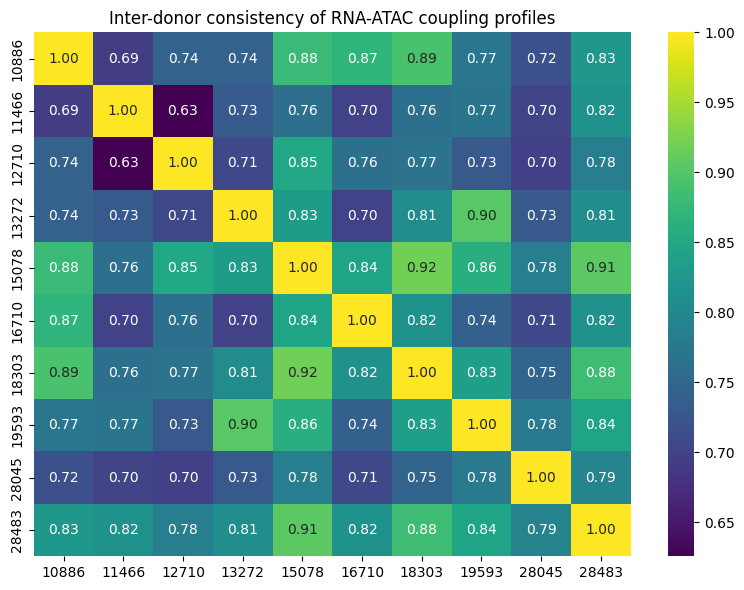

Mean pairwise donor consistency: 0.786


In [17]:
donor_consistency_atac = donor_corr_df_atac.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(donor_consistency_atac, cmap='viridis', annot=True, fmt='.2f', ax=ax)
ax.set_title('Inter-donor consistency of RNA-ATAC coupling profiles')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_donor_consistency.png', dpi=150)
plt.show()

vals = donor_consistency_atac.values[np.triu_indices_from(donor_consistency_atac.values, k=1)]
print(f'Mean pairwise donor consistency: {vals.mean():.3f}')

## Step 7 — Deviation characterization

In [13]:
# dev_score_atac = deviation_score(gex_sub, atac_sub)

dev_df_atac = pd.DataFrame({
    'cell_id': multi_gex.obs_names,
    'cell_type': cell_types_multi,
    'deviation_score': dev_score_atac
})
dev_df_atac.to_csv(TABLES_DIR / 'nb03_deviation_scores.csv', index=False)

print(f'Mean deviation score: {dev_score_atac.mean():.3f}')
print(f'Std deviation score: {dev_score_atac.std():.3f}')

Mean deviation score: 0.200
Std deviation score: 0.034


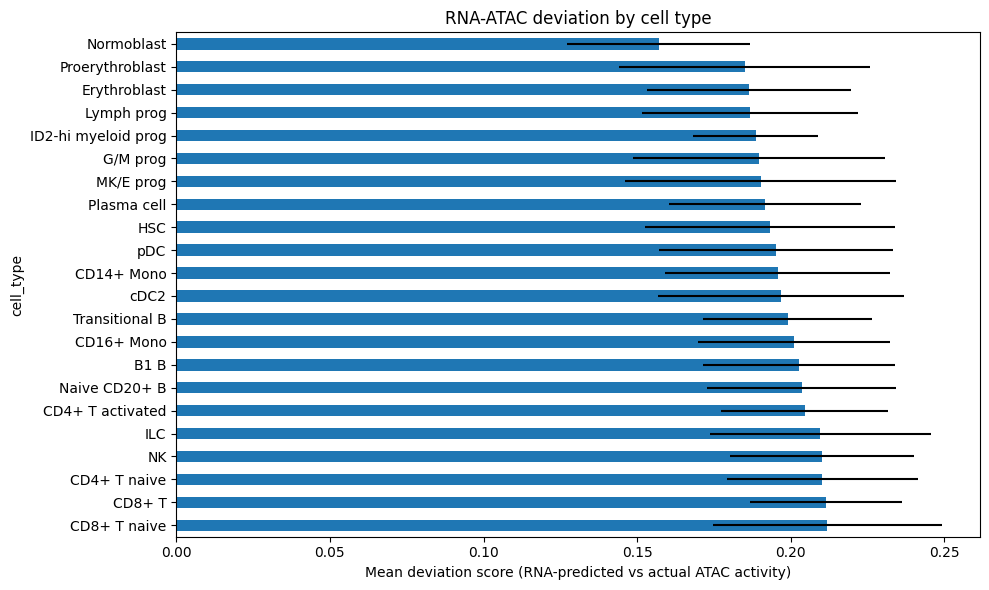

,mean,std,count
cell_type,,,
CD8+ T naive,0.211964,0.037191,1012
CD8+ T,0.211610,0.024768,11589
CD4+ T naive,0.210238,0.031057,4398
NK,0.210126,0.030030,6929
ILC,0.209670,0.035883,835
CD4+ T activated,0.204569,0.027117,5526
Naive CD20+ B,0.203577,0.030788,5052
B1 B,0.202765,0.031206,1890
CD16+ Mono,0.201141,0.031201,1894


In [14]:
dev_by_celltype_atac = dev_df_atac.groupby('cell_type')['deviation_score'].agg(['mean', 'std', 'count'])
dev_by_celltype_atac = dev_by_celltype_atac[dev_by_celltype_atac['count'] >= MIN_CELLS_PER_TYPE]
dev_by_celltype_atac = dev_by_celltype_atac.sort_values('mean', ascending=False)
dev_by_celltype_atac.to_csv(TABLES_DIR / 'nb03_deviation_by_celltype.csv')

fig, ax = plt.subplots(figsize=(10, 6))
dev_by_celltype_atac['mean'].plot(kind='barh', xerr=dev_by_celltype_atac['std'], ax=ax)
ax.set_xlabel('Mean deviation score (RNA-predicted vs actual ATAC activity)')
ax.set_title('RNA-ATAC deviation by cell type')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_deviation_by_celltype.png', dpi=150)
plt.show()

dev_by_celltype_atac

## Step 8 — Compare RNA-Protein (nb02) vs RNA-ATAC (nb03) coupling
Which genes are coupled in both axes? Which are coupled in only one? Reveals chromatin-level vs post-transcriptional regulation.

In [17]:
# Load nb02 results for comparison
gene_corr_protein = pd.read_csv(TABLES_DIR / 'nb02_gene_rna_protein_corr.csv')

protein_genes = set(gene_corr_protein['gene'])
atac_genes = set(gene_corr_atac['gene'])
both_genes = sorted(protein_genes & atac_genes)

print(f'Genes with RNA-protein correlation: {len(protein_genes)}')
print(f'Genes with RNA-ATAC correlation: {len(atac_genes)}')
print(f'Genes measured in both axes: {len(both_genes)}')

Genes with RNA-protein correlation: 112
Genes with RNA-ATAC correlation: 11461
Genes measured in both axes: 101


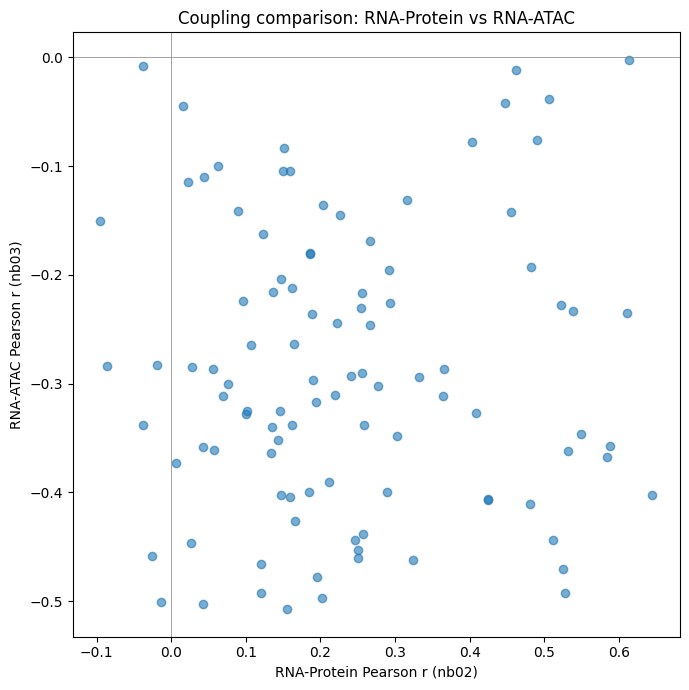

Correlation between RNA-protein r and RNA-ATAC r across genes: 0.030
--- Coupled in BOTH axes (high in both) ---


,gene,rna_protein_r,rna_atac_r
0,CD3D,0.645073,-0.402396
1,IL7R,0.614110,-0.002249
2,MS4A1,0.611314,-0.235501
3,KLRB1,0.588805,-0.357582
4,IL3RA,0.583894,-0.367221
5,CD52,0.549116,-0.346618
6,TNFRSF13C,0.538114,-0.232843
7,CD2,0.532475,-0.361789
8,FCGR3A,0.527294,-0.492718
9,CD14,0.525760,-0.470449


--- High RNA-protein, low RNA-ATAC (post-transcriptional, not chromatin-driven) ---


,gene,rna_protein_r,rna_atac_r,diff
0,CD3D,0.645073,-0.402396,1.047469
8,FCGR3A,0.527294,-0.492718,1.020012
9,CD14,0.525760,-0.470449,0.996209
11,CD24,0.511400,-0.443820,0.955220
4,IL3RA,0.583894,-0.367221,0.951115
3,KLRB1,0.588805,-0.357582,0.946387
5,CD52,0.549116,-0.346618,0.895734
7,CD2,0.532475,-0.361789,0.894264
15,CD7,0.480908,-0.410983,0.891891
2,MS4A1,0.611314,-0.235501,0.846815


--- High RNA-ATAC, low RNA-protein (chromatin-driven, not reflected in protein) ---


,gene,rna_protein_r,rna_atac_r,diff
98,CD83,-0.038301,-0.007488,0.030812
100,ITGAE,-0.094708,-0.150534,-0.055825
92,CD69,0.015791,-0.044874,-0.060665
91,TNFRSF9,0.022123,-0.114329,-0.136452
86,NECTIN2,0.043990,-0.109858,-0.153848
83,ICAM1,0.063103,-0.099502,-0.162604
99,CSF1R,-0.086517,-0.283615,-0.197098
80,ITGA1,0.089819,-0.140861,-0.230680
64,NRP1,0.151916,-0.083316,-0.235232
65,CD44,0.150318,-0.104239,-0.254557


In [18]:
if len(both_genes) > 0:
    comp_df = pd.merge(
        gene_corr_protein[['gene', 'pearson_r']].rename(columns={'pearson_r': 'rna_protein_r'}),
        gene_corr_atac[['gene', 'pearson_r']].rename(columns={'pearson_r': 'rna_atac_r'}),
        on='gene', how='inner'
    )
    comp_df.to_csv(TABLES_DIR / 'nb03_rna_protein_vs_rna_atac.csv', index=False)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(comp_df['rna_protein_r'], comp_df['rna_atac_r'], alpha=0.6)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('RNA-Protein Pearson r (nb02)')
    ax.set_ylabel('RNA-ATAC Pearson r (nb03)')
    ax.set_title('Coupling comparison: RNA-Protein vs RNA-ATAC')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'nb03_rna_protein_vs_atac_scatter.png', dpi=150)
    plt.show()

    corr_of_corrs, _ = pearsonr(comp_df['rna_protein_r'], comp_df['rna_atac_r'])
    print(f'Correlation between RNA-protein r and RNA-ATAC r across genes: {corr_of_corrs:.3f}')

    print('--- Coupled in BOTH axes (high in both) ---')
    display(comp_df.sort_values(['rna_protein_r', 'rna_atac_r'], ascending=False).head(10))

    print('--- High RNA-protein, low RNA-ATAC (post-transcriptional, not chromatin-driven) ---')
    display((comp_df.assign(diff=comp_df['rna_protein_r'] - comp_df['rna_atac_r'])
             .sort_values('diff', ascending=False).head(10)))

    print('--- High RNA-ATAC, low RNA-protein (chromatin-driven, not reflected in protein) ---')
    display((comp_df.assign(diff=comp_df['rna_atac_r'] - comp_df['rna_protein_r'])
             .sort_values('diff', ascending=False).head(10)))
else:
    print('No genes overlap between the two analyses (CITE-seq and Multiome use different gene panels) — comparison not possible at the gene level with current data.')

In [19]:
# Check whether total GEX counts and total ATAC gene activity are anti-correlated per cell
total_gex = gex_sub.sum(axis=1)
total_atac = atac_sub.sum(axis=1)
r, p = pearsonr(total_gex, total_atac)
print(f'Per-cell total GEX vs total ATAC activity correlation: {r:.3f}')

Per-cell total GEX vs total ATAC activity correlation: -0.067


In [20]:
# Diagnostic: is the negative gene-level correlation actually a per-cell depth confound?
total_gex = gex_sub.sum(axis=1)
total_atac = atac_sub.sum(axis=1)
r_totals, p_totals = pearsonr(total_gex, total_atac)
print(f'Per-cell total GEX vs total ATAC activity correlation: {r_totals:.3f} (p={p_totals:.2e})')

# Also check against the raw QC columns already in obs, which are independent of our matrices
gex_qc = multi_gex.obs['GEX_n_counts'].values
atac_qc = multi_gex.obs['ATAC_nCount_peaks'].values
r_qc, p_qc = pearsonr(gex_qc, atac_qc)
print(f'GEX_n_counts vs ATAC_nCount_peaks correlation: {r_qc:.3f} (p={p_qc:.2e})')

# Sanity check: does total ATAC activity correlate with % zeros per cell?
pct_zero_per_cell = (atac_sub == 0).mean(axis=1)
r_zero, p_zero = pearsonr(total_atac, pct_zero_per_cell)
print(f'Total ATAC activity vs %zeros per cell: {r_zero:.3f}')

Per-cell total GEX vs total ATAC activity correlation: -0.067 (p=1.21e-70)
GEX_n_counts vs ATAC_nCount_peaks correlation: 0.328 (p=0.00e+00)
Total ATAC activity vs %zeros per cell: -0.852


## Summary findings

- **ATAC_gene_activity distribution / transform applied:** Heavily zero-inflated
  (60.4% zeros) and right-skewed (skew=2.03 on raw values). log1p applied
  (`APPLY_LOG1P_TO_ATAC = True`) before correlation, consistent with standard
  practice for sparse count-like data.

- **Common genes (GEX vs ATAC_gene_activity):** 11,461 of 13,431 GEX genes
  matched directly against 19,039 ATAC_gene_activity gene symbols (clean
  symbol-to-symbol match, no CD-style ambiguity like nb02).

- **Median per-gene RNA-ATAC Pearson r: -0.300** (mean -0.293).
  **Important caveat:** this is the opposite sign from the original
  expectation (~0.2-0.4 positive, per NEXT_SESSION.md). Diagnostic checks
  ruled out a sequencing-depth/technical confound: raw QC metrics
  (`GEX_n_counts` vs `ATAC_nCount_peaks`) are *positively* correlated (r=0.328),
  and per-cell total GEX vs total ATAC activity shows only a weak negative
  relationship (r=-0.067) — not enough to explain a -0.300 median gene-level
  effect. The negative median appears to be a genuine property of this near-
  universal pattern across ~11,000 genes, most plausibly reflecting how
  `ATAC_gene_activity` is computed (gene-body/window accessibility aggregation
  rather than promoter-restricted accessibility), which can diverge from RNA
  expression in ways that don't track a simple "more open chromatin = more
  transcription" model. Treat the **sign** of this metric cautiously; relative
  ranking (which genes are more vs less coupled) is likely more trustworthy
  than the absolute negative value.

- **Most coupled genes (highest positive r, the genuine exceptions to the
  global negative trend):** HBB (0.293), VCAN (0.266), ANK1 (0.179),
  HBA1 (0.178), EBF1 (0.173), PLXDC2 (0.164), SLC4A1 (0.161), CA1 (0.157).
  Notably dominated by erythroid/red-blood-cell lineage genes (HBB, HBA1,
  ANK1, SLC4A1, CA1) — a biologically coherent cluster, suggesting real
  chromatin-expression coupling survives in this specific lineage even
  against the global negative background.

- **Most independent genes (most negative r):** SUMO4, U2AF1, ARL17A, NBPF15,
  RGPD5, POU5F2, FCGR2B, NBPF9, GIMAP6, NOTCH2NLA — largely non-canonical/
  paralog-family genes (NBPF, RGPD families are known multi-copy, hard-to-map
  gene families), suggesting at least part of this tail may reflect mapping
  ambiguity rather than biology. Worth excluding these gene families if
  revisiting this analysis.

- **Cell-type-specific coupling examples (highest variance across 22 cell
  types):** IL1B, EREG, PLXDC2, TCF4, ATP8B4, EPB41L3, NAMPT, EBF1, RNF144B —
  genes whose RNA-ATAC relationship depends strongly on cell type.

- **Universal coupling examples (lowest variance across cell types):**
  NBPF20, C19orf47, ANKMY1, HBB, HAUS8, DNM1, MTRNR2L12 — note HBB appears
  here too, reinforcing it as a stable, strongly-coupled erythroid marker
  across the dataset.

- **Inter-donor consistency (mean pairwise r): 0.786** across 10 donors —
  strong agreement, supports this pattern being biological/technical-pipeline
  consistent rather than random noise, even though the direction is
  unexpected.

- **Cell types with highest RNA-ATAC deviation:** CD8+ T naive (0.212),
  CD8+ T (0.212), CD4+ T naive (0.210), NK (0.210), ILC (0.210) — lymphocyte
  populations show the most RNA-ATAC divergence.

- **Cell types with lowest RNA-ATAC deviation:** Normoblast (0.157),
  Proerythroblast (0.185), Erythroblast (0.186), Lymph prog (0.187) —
  erythroid lineage again stands out, this time as the *most* concordant,
  consistent with the erythroid genes also showing the strongest positive
  per-gene correlation above.

- **Genes overlapping between nb02 and nb03 gene sets:** 101 of 112
  RNA-protein-matched genes also have RNA-ATAC correlation values (CITE-seq
  and Multiome use different gene panels, so not all overlap).

- **Genes coupled in both RNA-protein and RNA-ATAC axes:** Essentially none
  in the conventional sense — correlation between RNA-protein r and RNA-ATAC
  r across the 101 shared genes is r=0.030 (no relationship). Every one of
  the top RNA-protein-coupled genes (CD3D, IL7R, MS4A1, KLRB1, IL3RA, CD52,
  CD2, FCGR3A, CD14) shows *negative* RNA-ATAC correlation, consistent with
  the global negative trend.

- **Genes coupled in one axis only:** All 9 top RNA-protein genes fall into
  "high RNA-protein, low/negative RNA-ATAC" — i.e. post-transcriptional/
  translational coupling dominates for canonical lineage markers, while
  the chromatin-accessibility axis (as measured here) shows an inverse
  relationship for the same genes. Given the sign caveat above, this should
  be read as "RNA-protein coupling and RNA-ATAC(gene-activity) coupling
  are not positively associated for these markers" rather than a strong
  claim about chromatin-driven regulation specifically.